In [2]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


Load GC Data: 100%|██████████| 12684/12684 [00:43<00:00, 290.33it/s]
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_34500\2881436916.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_34500\2881436916.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_34500\2881436916.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap

(np.float64(-18.211217),
 np.float64(48.87326083782486),
 np.float64(-3.810840485726682),
 np.float64(51.4345235079897))

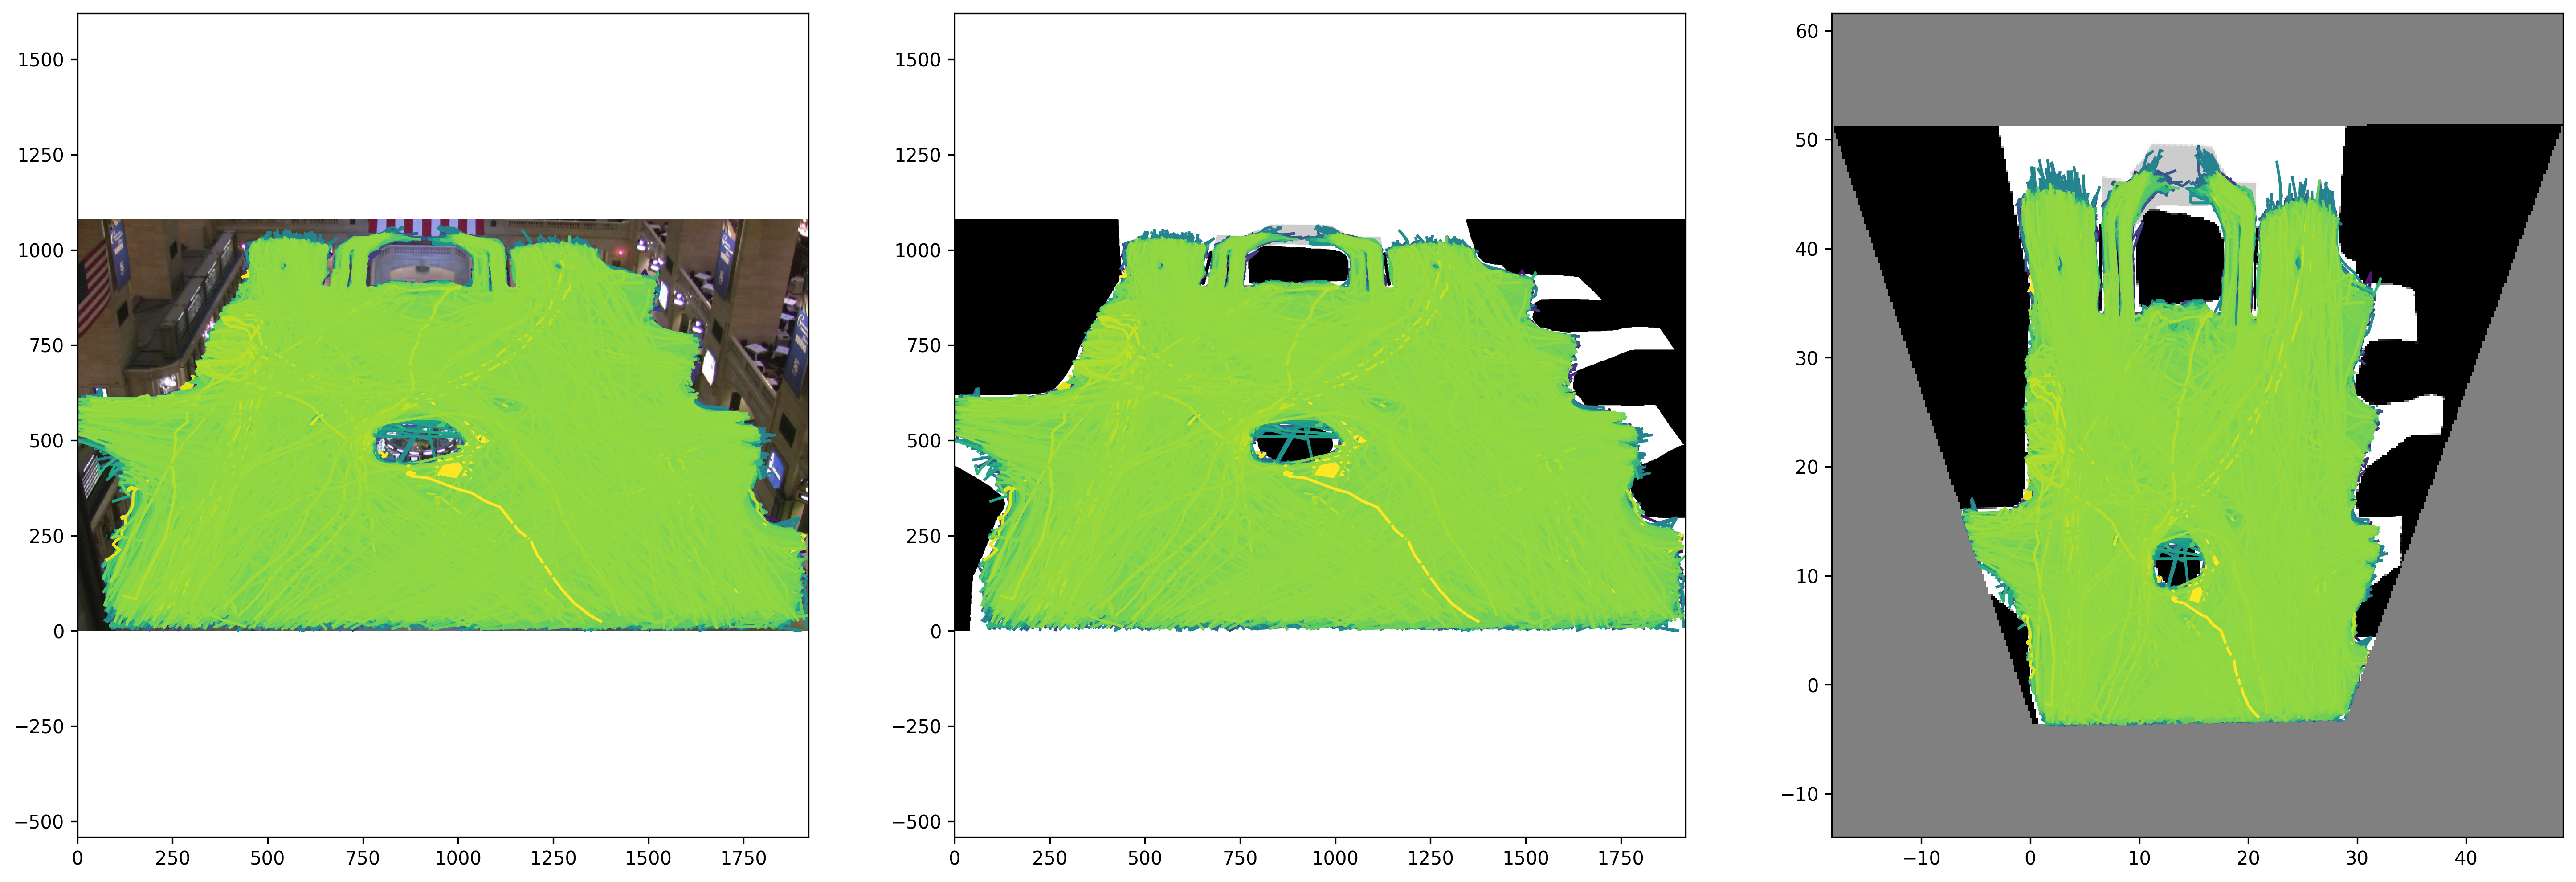

In [3]:
import os
import sys
import torch
import logging
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from typing import List
from io import StringIO
from pathlib import Path
from argparse import Namespace
from scipy.interpolate import griddata
from src.dataset.base_dataset import BaseDataset
from src.dataset.gc_dataset import GCDataset
from src.utils.homography import calc_homography_mat, affine_transformation, image_to_world
import matplotlib.pyplot as plt

data_path = Path('data/GC/Annotation')
name = "GC"

## 读取数据
H = GCDataset.get_homography_mat()  # (3, 3)
df_data = []
for file in tqdm(sorted(data_path.glob('*.txt')), desc="Load GC Data"):
    xyf = np.loadtxt(file).reshape(-1, 3)
    df = pd.DataFrame(xyf, columns=['x', 'y', 'f'])
    df[['raw_x', 'raw_y']] = df[['x', 'y']]
    df[['x', 'y']] = affine_transformation(df[['x', 'y']].values, H)
    df['abnormal'] = GCDataset.get_abnormal(df, min_abnormal_speed=5.0, min_abnormal_whis=3.0)
    df['id'] = int(file.stem)
    df['type'] = 'pedestrian'
    df_data.append(df)
df_data = pd.concat(df_data, ignore_index=True)

## 移除异常点
df_data = df_data[~df_data['abnormal']]

## 数据重采样
df_data = BaseDataset.resample_dataframe(df_data, raw_fps=GCDataset.raw_fps, target_fps=2.5)
df_data[['raw_x', 'raw_y']] = affine_transformation(df_data[['x', 'y']].values, np.linalg.inv(H))

## 读取地图
image = np.array(Image.open(data_path.parent / f"map.png").convert('L'))  # (H, W)  第一维向下，第二维向右
image = image.T # 转置，使得第一维向右，第二维向下，与 df_data 中的坐标系对齐
map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5)  # 第一维向右，第二维向上，即 xy 坐标

## 可视化
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
image0 = np.array(Image.open('data/GC/Demo.jpg'))  # (H, W)  第一维向下，第二维向右
h, w = image0.shape[:2]
axes[0].imshow(image0, extent=(0, w, 0, h))  # 第一维向下、第二维向右：直接用 imshow 显示
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[0].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[0].axis('equal')
h, w = image.T.shape[:2]
axes[1].imshow(image.T, extent=(0, w, 0, h), cmap='gray_r')  # 第一维向右，第二维向下：转置后用 imshow 正常显示
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[1].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[1].axis('equal')
axes[2].imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[2].plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[2].set_facecolor('gray')
axes[2].axis('equal')

# Backup

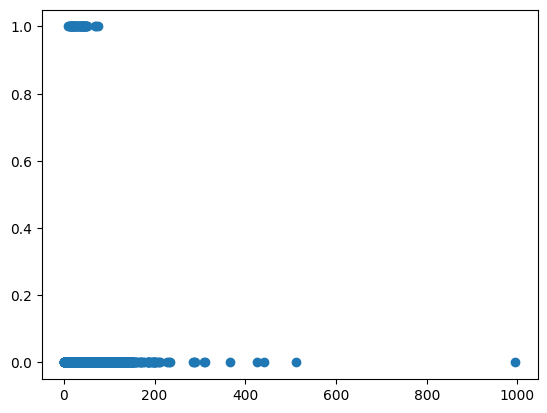

In [152]:
tmp = []
for pid, group in df_data.groupby('id'):
    keep = group['abnormal'].eq(False).sum()
    remove = group['abnormal'].eq(True).sum()
    tmp.append({'keep': keep, 'remove': remove, 'id': pid})
tmp = pd.DataFrame(tmp)
plt.scatter(tmp['keep'], tmp['remove'])

In [155]:
tmp.sort_values('remove', ascending=False).head(20)

,keep,remove,id
4780,30,1,4781
4940,34,1,4941
5265,14,1,5266
4803,21,1,4804
12668,44,1,12669
3536,16,1,3537
1059,40,1,1060
1599,23,1,1600
1115,15,1,1116
3995,44,1,3996


C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\2853517603.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\2853517603.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\2853517603.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


(np.float64(-18.211217),
 np.float64(48.87326083782486),
 np.float64(-3.810840485726682),
 np.float64(51.4345235079897))

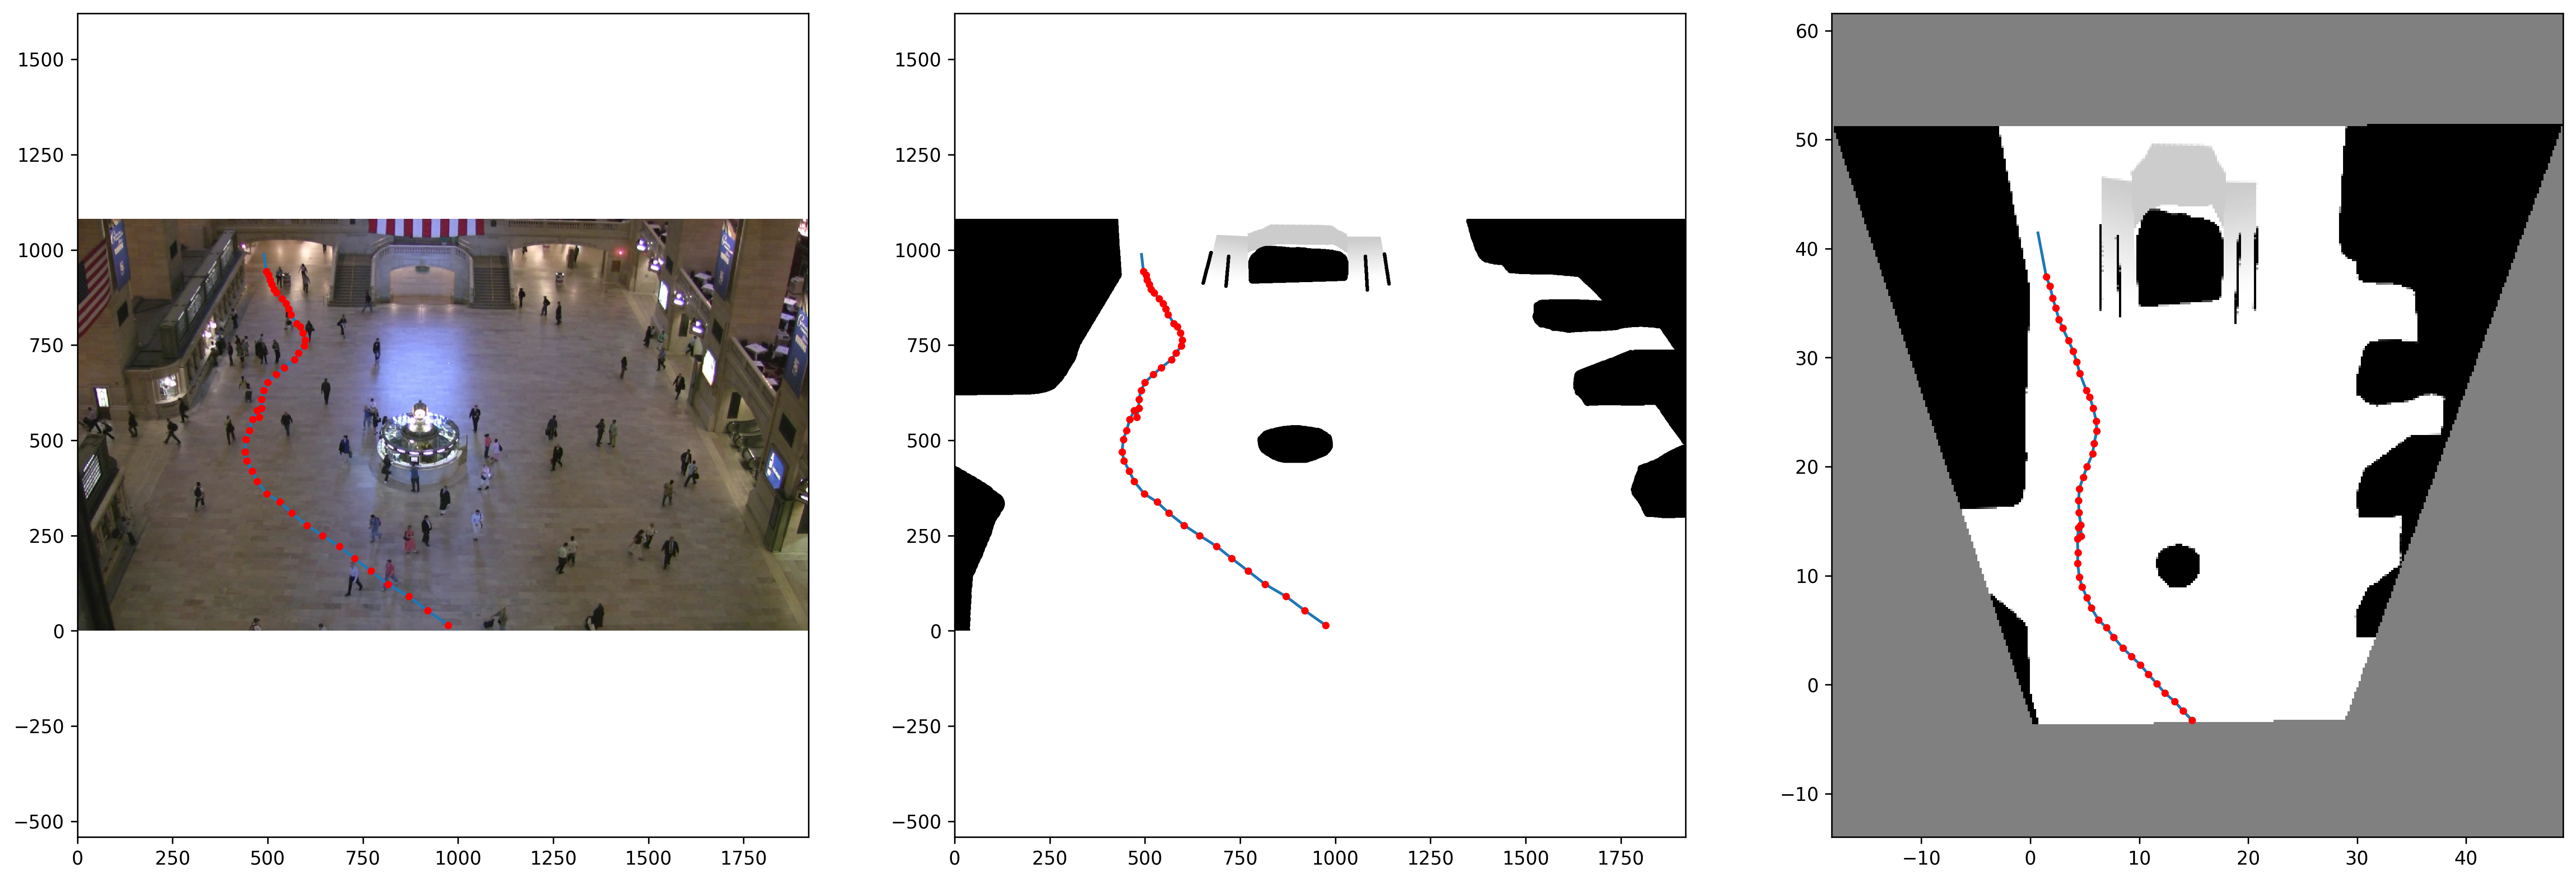

In [ ]:
## 可视化
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
image0 = np.array(Image.open('data/GC/Demo.jpg'))  # (H, W)  第一维向下，第二维向右
h, w = image0.shape[:2]
axes[0].imshow(image0, extent=(0, w, 0, h))  # 第一维向下、第二维向右：直接用 imshow 显示
group = df_data[df_data['id'] == 6007]
cmap = plt.cm.get_cmap('viridis')
axes[0].plot(group['raw_x'], 1080-group['raw_y'])  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
group = group[~group['abnormal']]
axes[0].plot(group['raw_x'], 1080-group['raw_y'], 'r.')  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[0].axis('equal')

h, w = image.T.shape[:2]
axes[1].imshow(image.T, extent=(0, w, 0, h), cmap='gray_r')  # 第一维向右，第二维向下：转置后用 imshow 正常显示
group = df_data[df_data['id'] == 6007]
cmap = plt.cm.get_cmap('viridis')
# axes[1].plot(group['raw_x'], 1080-group['raw_y'])  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
# group = group[~group['abnormal']]
# axes[1].plot(group['raw_x'], 1080-group['raw_y'], 'r.')  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[1].axis('equal')

axes[2].imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
group = df_data[df_data['id'] == 6007]
cmap = plt.cm.get_cmap('viridis')
axes[2].plot(group['x'], group['y'])
group = group[~group['abnormal']]
axes[2].plot(group['x'], group['y'], 'r.')  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[2].set_facecolor('gray')
axes[2].axis('equal')

In [136]:
df_ = df_data[df_data['id'] == 4633]

df_.sort_values(by='f').reset_index(drop=True)
diff1 = df_[['x', 'y']].diff(axis=0).pow(2).sum(axis=1).pow(0.5).div(df_['f'].diff())
diff2 = -df_[['x', 'y']].diff(-1, axis=0).pow(2).sum(axis=1).pow(0.5).div(df_['f'].diff(-1))
diff = pd.concat([diff1, diff2], axis=1).min(axis=1)
quantiles = diff.quantile([0.25, 0.75])
IQR = quantiles.loc[0.75] - quantiles.loc[0.25]
upper_bound = quantiles.loc[0.75] + 3.0 * IQR
abnormal = (diff > upper_bound) & (diff > 5)
abnormal

171116    False
171117    False
171118    False
171119    False
171120    False
171121    False
171122    False
171123     True
171124    False
171125    False
171126    False
171127    False
171128    False
dtype: bool

In [190]:
df_data = df_data[~df_data['abnormal']]

In [65]:
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    if ((group['raw_x'] > 1750) & (1080-group['raw_y'] > 600)).any():
        print(pid)
        break
else:
    print("没这回事")


C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\2410907624.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


9393


C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\3523449556.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\3523449556.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
C:\Users\YuMeow\AppData\Local\Temp\ipykernel_12208\3523449556.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


(np.float64(-18.211217),
 np.float64(48.87326083782486),
 np.float64(-3.810840485726682),
 np.float64(51.4345235079897))

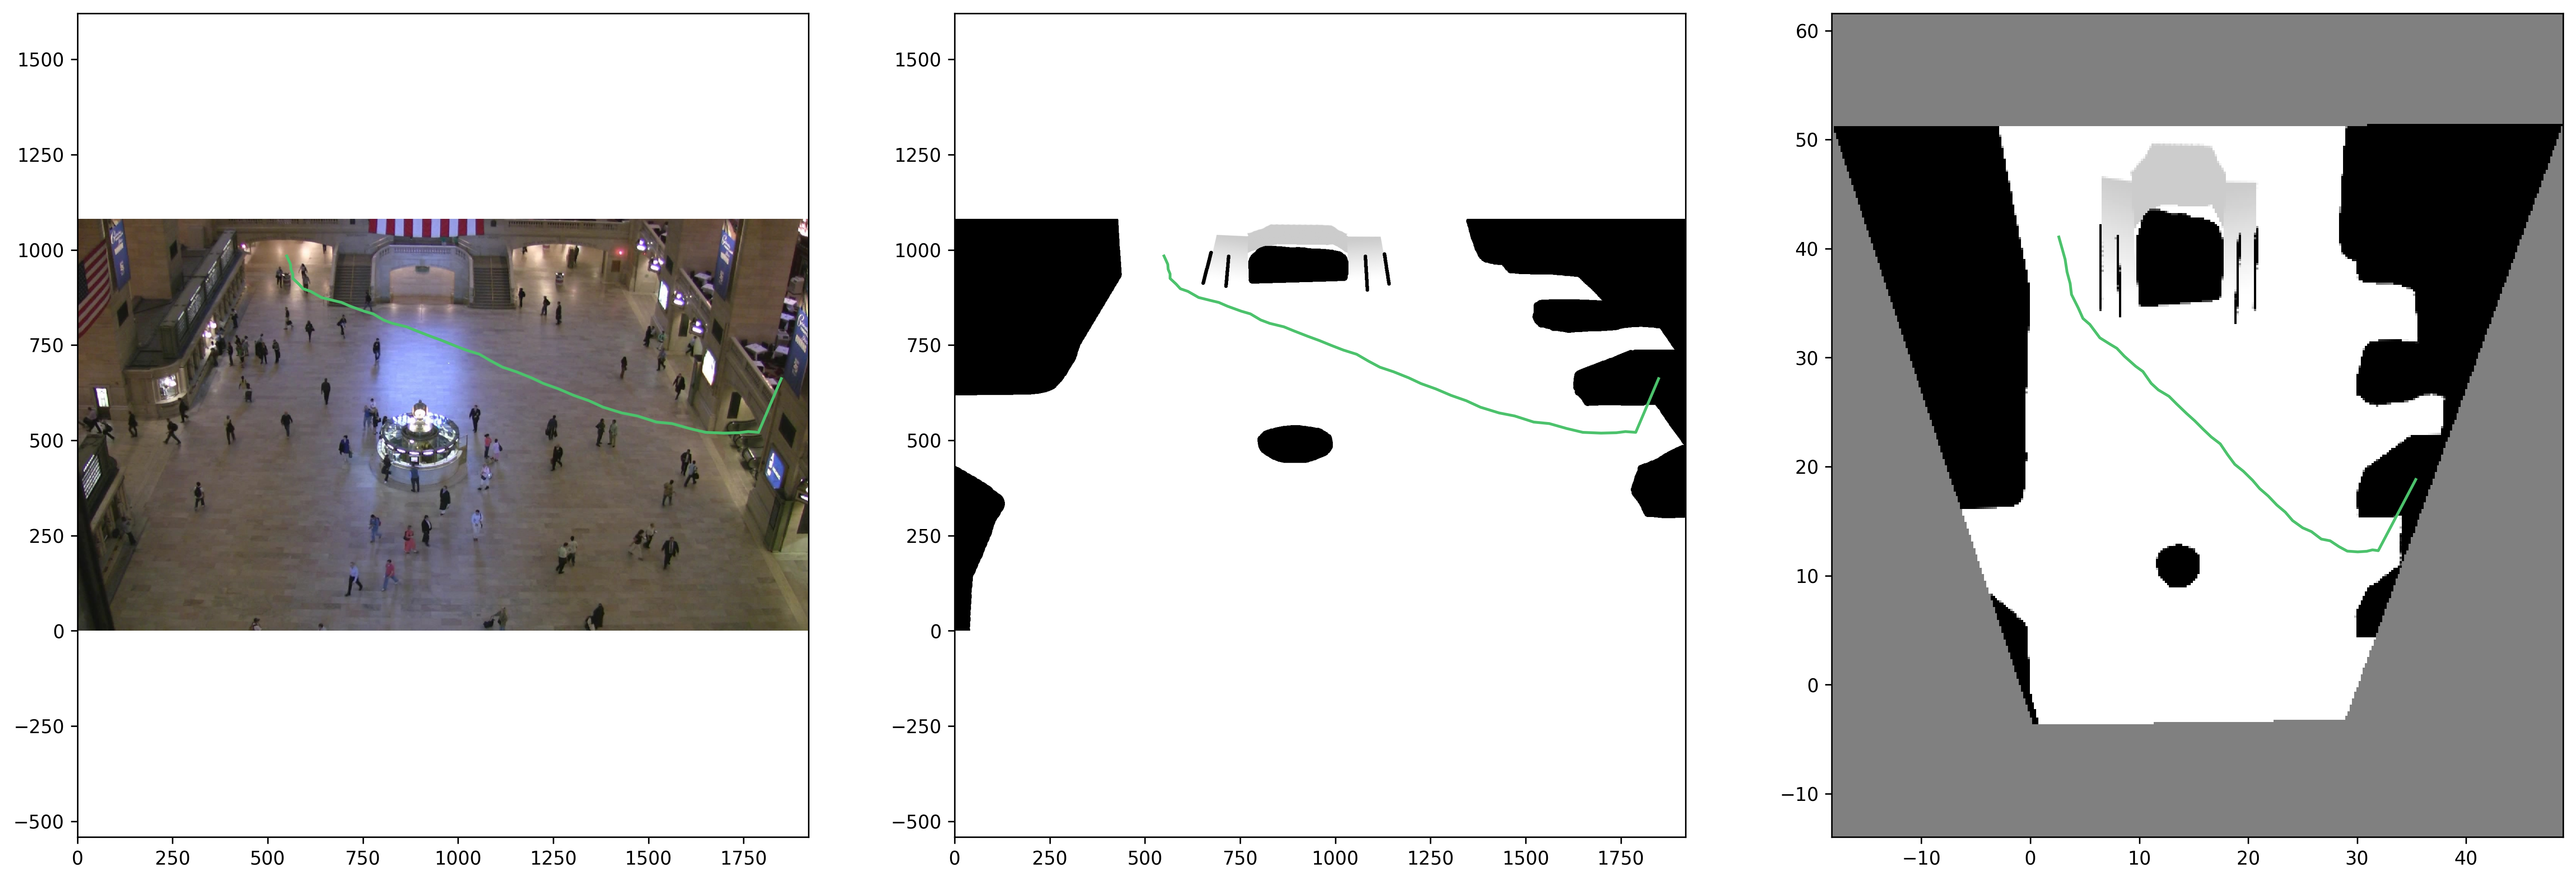

In [66]:
## 可视化
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
image0 = np.array(Image.open('data/GC/Demo.jpg'))  # (H, W)  第一维向下，第二维向右
h, w = image0.shape[:2]
axes[0].imshow(image0, extent=(0, w, 0, h))  # 第一维向下、第二维向右：直接用 imshow 显示
group = df_data[df_data['id'] == pid]
cmap = plt.cm.get_cmap('viridis')
axes[0].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[0].axis('equal')

h, w = image.T.shape[:2]
axes[1].imshow(image.T, extent=(0, w, 0, h), cmap='gray_r')  # 第一维向右，第二维向下：转置后用 imshow 正常显示
group = df_data[df_data['id'] == pid]
cmap = plt.cm.get_cmap('viridis')
axes[1].plot(group['raw_x'], 1080-group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向下：将 y 轴翻转后正常 xy 绘制
axes[1].axis('equal')

axes[2].imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
group = df_data[df_data['id'] == pid]
cmap = plt.cm.get_cmap('viridis')
axes[2].plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[2].set_facecolor('gray')
axes[2].axis('equal')

In [68]:
xyf = np.loadtxt('./data/GC/Annotation/009393.txt').reshape(-1, 3)
df = pd.DataFrame(xyf, columns=['x', 'y', 'f'])

df.sort_values(by='f').reset_index(drop=True)
diff1 = df[['x', 'y']].diff(axis=0).pow(2).sum(axis=1).pow(0.5).div(df['f'].diff())
diff2 = -df[['x', 'y']].diff(-1, axis=0).pow(2).sum(axis=1).pow(0.5).div(df['f'].diff(-1))
abnormal1 = diff1.gt(10)
abnormal2 = diff2.gt(10)
abnormal = abnormal1 | abnormal2
# if abnormal.any(): 
#     df = df[~abnormal].reset_index(drop=True)
# else:
#     break

diff2

0     0.715891
1     0.492443
2     0.651920
3     0.650000
4     0.600000
5     1.096586
6     0.813941
7     1.059481
8     1.612452
9     1.649242
10    1.079352
11    1.253994
12    1.913766
13    1.250000
14    1.569235
15    1.281601
16    1.903943
17    1.457738
18    1.931321
19    1.597655
20    1.726992
21    1.662077
22    1.834394
23    1.792345
24    1.700000
25    1.897367
26    2.154066
27    1.767060
28    2.071835
29    2.173131
30    2.118962
31    2.035927
32    2.562226
33    2.088660
34    2.624881
35    2.059733
36    2.390084
37    2.158703
38    2.402082
39    2.000625
40    1.209339
41    1.353699
42    7.661756
43         NaN
dtype: float64

In [25]:
df_data.groupby('id')

TypeError: unsupported operand type(s) for -: 'str' and 'str'